In [2]:
# 如果需要，可取消注释并改成你的路径
import sys
# sys.path.append(r'.')

from importlib import reload
import os
import low_cut_utils_modified as ref 
reload(ref)
from low_cut_utils_modified import *
import numpy as np
from lgdo import lh5
import numpy as np
import awkward as ak
from lgdo import lh5
import pandas as pd
import matplotlib.pyplot as plt


/tmp/ipykernel_3857820/2298729575.py:11: DeprecationWarning: lgdo.lh5 has moved to its own package, legend-lh5io. Please replace 'import lgdo.lh5' with 'import lh5'. lgdo.lh5 will be removed in a future release.
  from lgdo import lh5


In [3]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "05"
run_cal = "057"

# bg run 6 days
pnum_phy_bg = "00"
run_phy_bg = "038"
# signal run 13 days
pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]



def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)

        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")
        missing_this_run = []
        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")
        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "time_ns": int(m.group(1)),
            "mw": int(m.group(2)),
            "interval": f"{m.group(1)}ns",
            "mw_label": f"mw{m.group(2)}",
            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,
            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,
            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )
    return db
run_db = build_run_db(runs, filepath)


In [4]:
all_summary = load_pkl("/mnt/atlas02/users/leoli/AoverE_analysis/low_cuts/all_lowcut_event_classifier_db_r57r59.pkl")

loaded from /mnt/atlas02/users/leoli/AoverE_analysis/low_cuts/all_lowcut_event_classifier_db_r57r59.pkl


In [5]:
aoe_field = 'A_max_mw_o_E_Timecorr'
low_cut_field = 'A_max_mw_o_E_fix_Low_Cut'
energy_field = 'trapEftp_fix_cal'
run = 's100ns_mw5'
index = 1   # ch001 -> 0, ch002 -> 1

In [6]:
def plot_lowcut_hist_from_event_db(
    event_db,
    bins: int = 200,
    value_range: Tuple[float, float] = (0.75, 1.25),
    ylim_top: float = 1e6,
    show_labels=("DEP", "FEP", "ROI_BG", "ROI_Signal"),
    save_fig: Optional[str] = None,
    show_plot: bool = True,
):
    hist_db = make_hist_db_from_event_db(
        event_db,
        bins=bins,
        value_range=value_range,
    )

    label_map = {
        "DEP": "DEP",
        "FEP": "FEP",
        "ROI_BG": "ROI BG",
        "ROI_Signal": "ROI Signal",
    }

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.set_title(
        f"A/E spectrum| sp01 | r059 | IC | {event_db['meta']['run']}"
    )

    # Create inset ONCE
    ax_inset = ax.inset_axes([0.23, 0.1, 0.3, 0.3])

    for key in show_labels:
        centers = hist_db[key]["centers"]
        total = hist_db[key]["counts"]

        # label = f"{label_map.get(key, key)} total"

        # Main plot
        ax.step(
            centers,
            total,
            where="mid",
            # label=label,
        )

        # Inset plot: same centers, same counts -> same binning
        ax_inset.step(
            centers,
            total,
            where="mid",
            # label=label,
            color = "C1"
        )

    # Main axis style
    ax.set_xlabel(event_db["meta"]["aoe_field"])
    ax.set_ylabel("Counts")
    ax.set_yscale("log")
    ax.set_ylim(1, ylim_top)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    # Inset style
    ax_inset.set_xlim(-10, 5)
    ax_inset.set_yscale("log")
    ax_inset.set_ylim(0.5e1, 3e3)
    ax_inset.set_title("Zoomed Inset", fontsize=8)
    ax_inset.tick_params(labelsize=8)
    ax_inset.grid(alpha=0.25)

    plt.tight_layout()

    if save_fig is not None:
        plt.savefig(save_fig)
        print(f"Figure saved to {save_fig}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    return hist_db

/tmp/ipykernel_3857820/1332926540.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


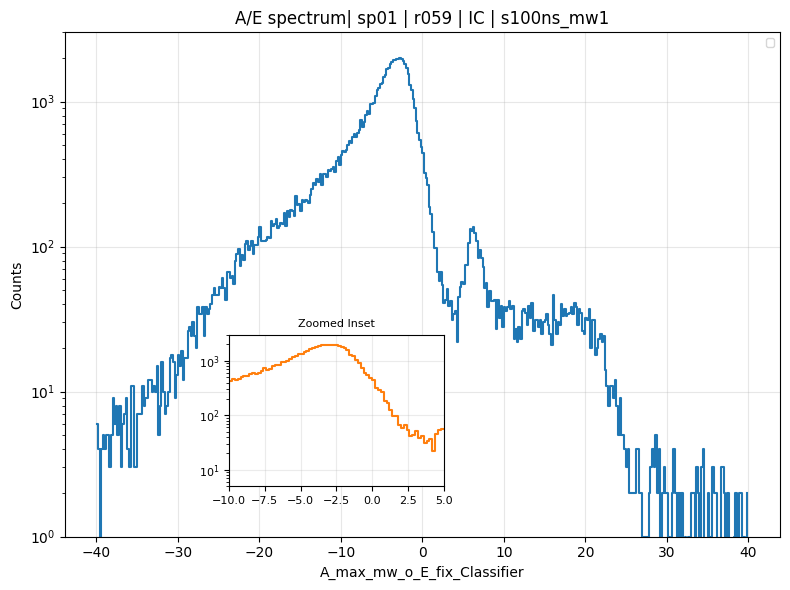

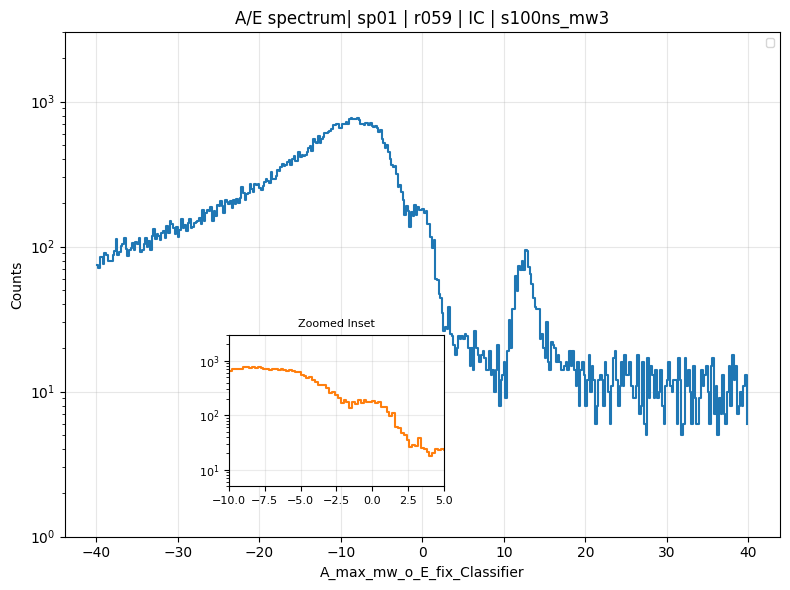

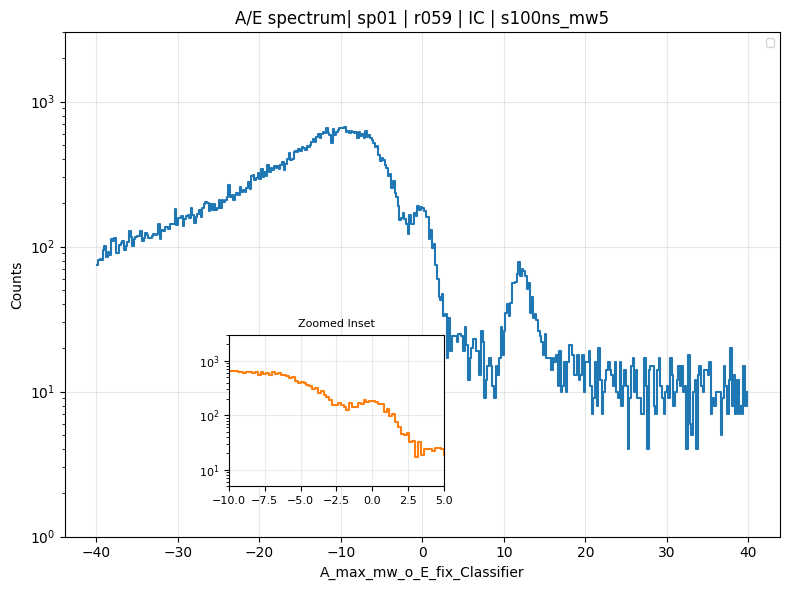

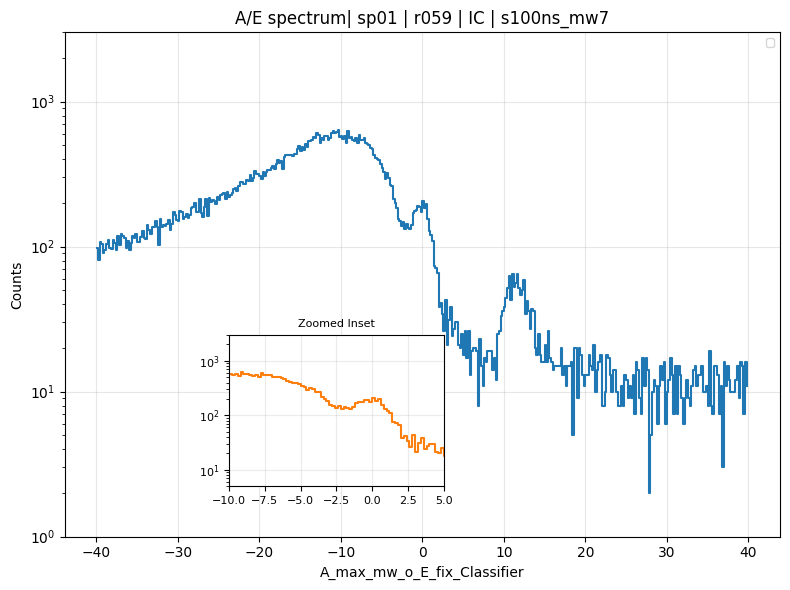

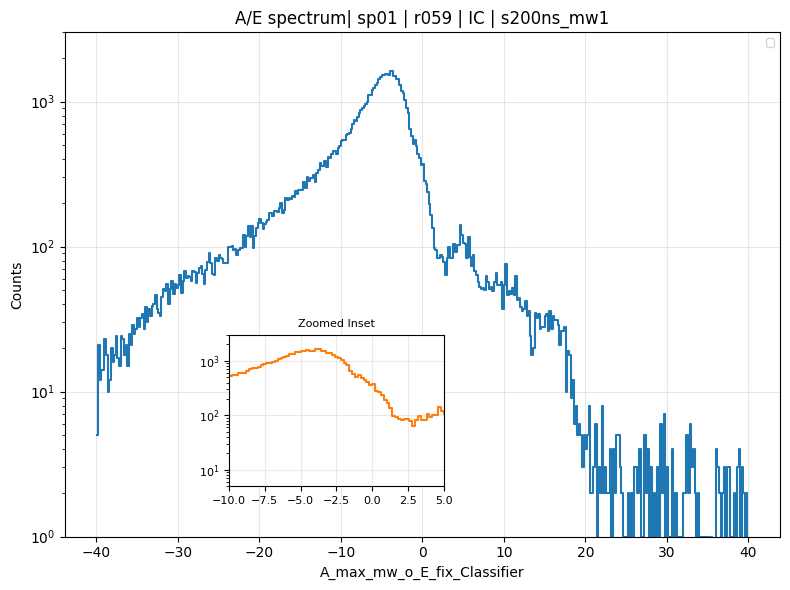

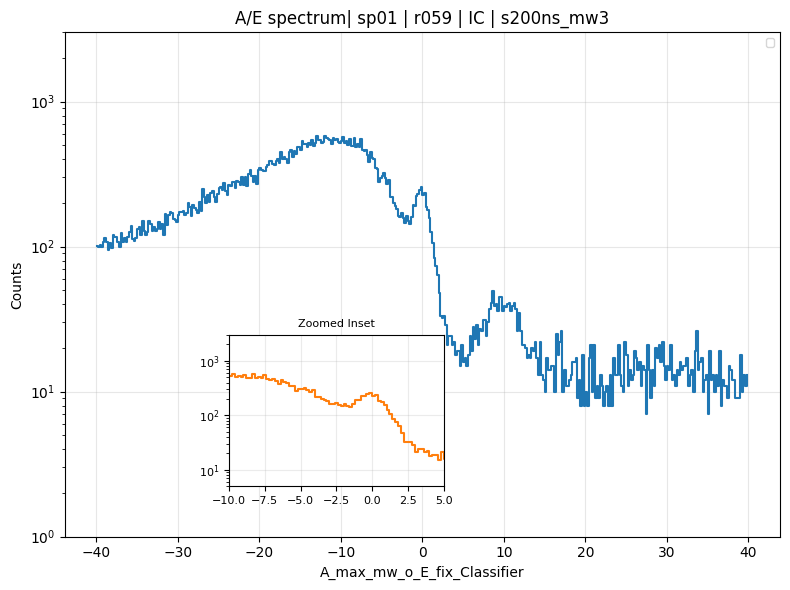

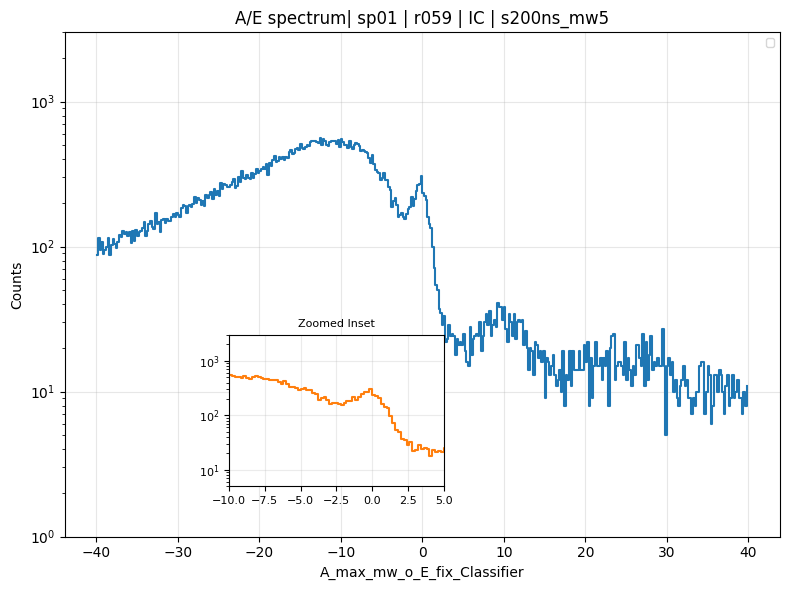

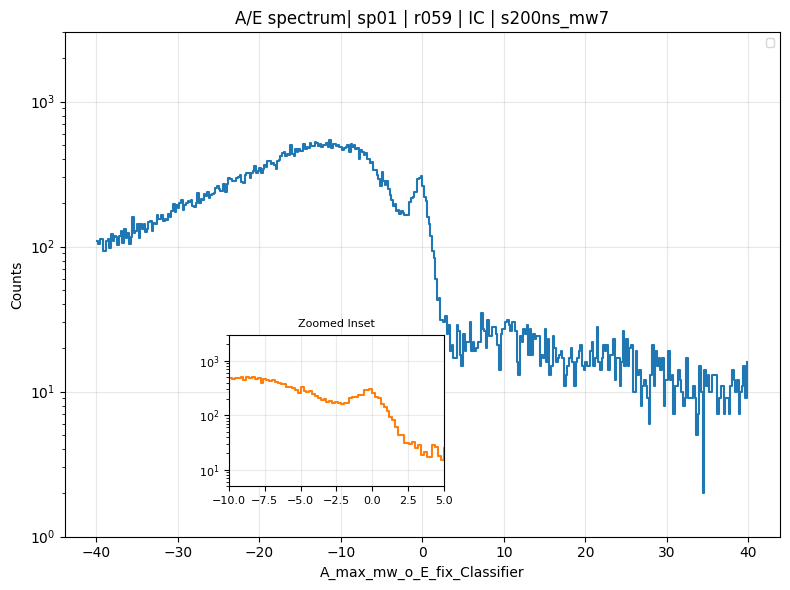

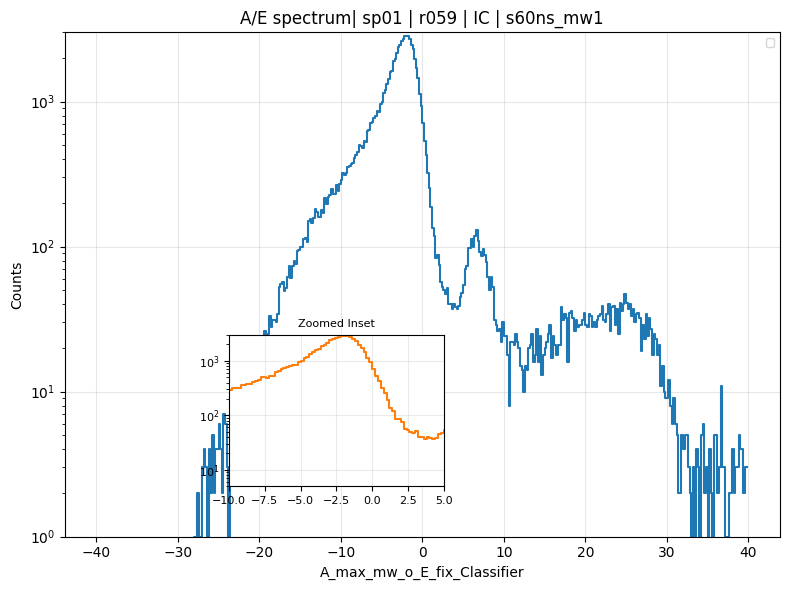

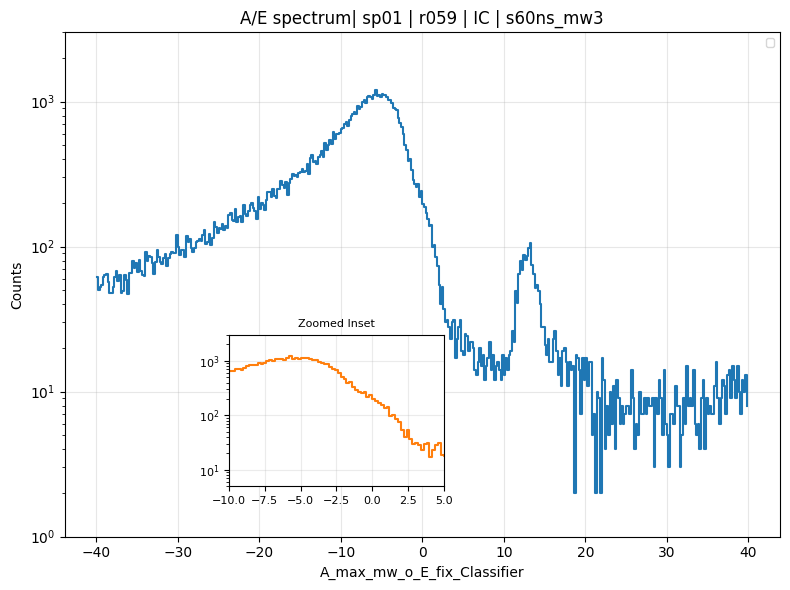

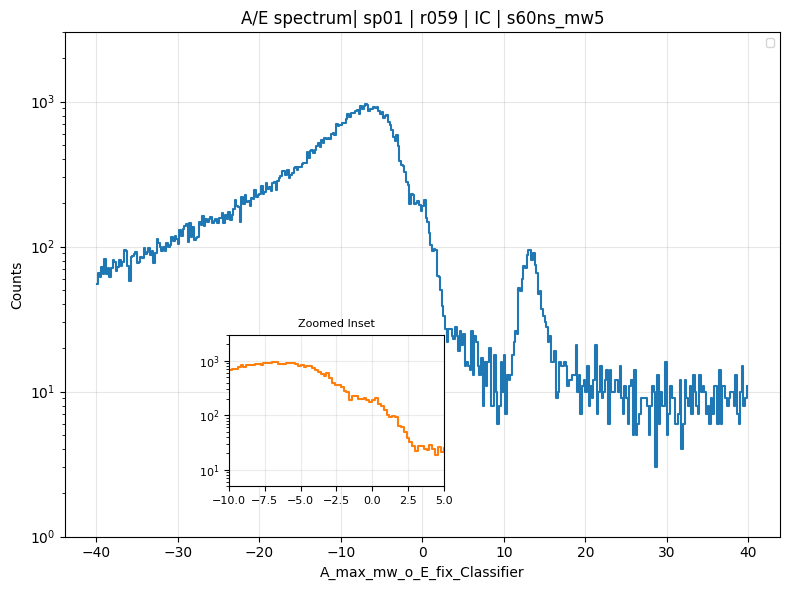

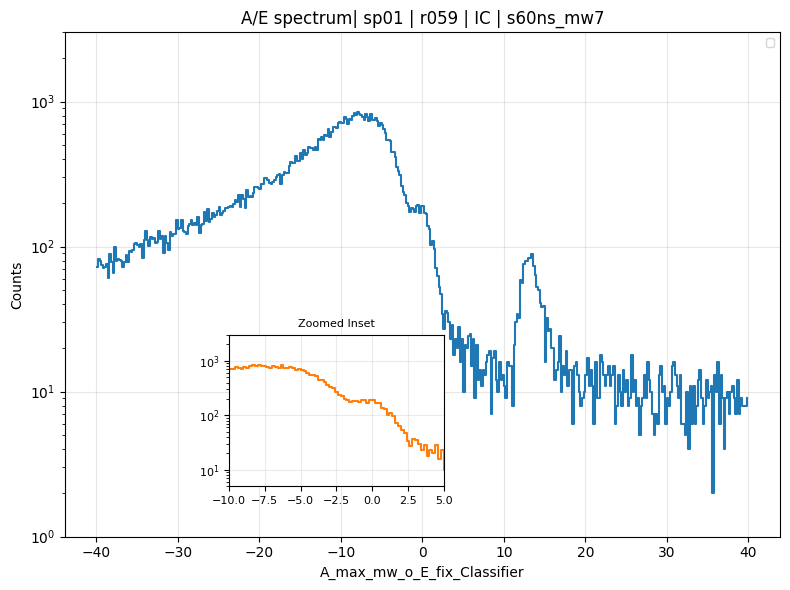

In [7]:
for run, run_dict in all_summary.items():
    for channel, res in run_dict.items():
        if res.get("status") != "ok":
            print(f"skip {run} {channel}: {res.get('error')}")
            continue
        event_db = res["event_db"]
        hist_db = plot_lowcut_hist_from_event_db(
            event_db,
            bins=400,
            value_range=(-40, 40),
            show_labels=("ROI_Signal",),
            ylim_top=3e3
        )